# CNN from Scratch: LeNet → Modern Blocks

This notebook is a self-contained, step-by-step guide to building and improving convolutional neural networks in PyTorch. We start from the original LeNet (1998) and evolve the architecture one idea at a time — so you can measure the contribution of each block.

**What you will learn:**
1. Build and train LeNet on CIFAR-10.
2. Replace and add architectural blocks: strided convolution, BatchNorm, GAP, cascaded convolutions, depthwise separable convolutions, residual connections, SE-squeeze.
3. Compare all variants in a single table.
4. Perform **data-centric** analysis: confusion matrix, hard samples, what the network actually looks at (Grad-CAM).

> **Runs on Colab GPU.** Runtime → Change runtime type → T4 GPU.

## [Open in Colab](https://colab.research.google.com/github/MVRonkin/DLCVCourseEn/tree/main/WS/WS2_CNN_From_Scratch.ipynb)

# 1. Setup

In [10]:
!pip install --quiet -U torchinfo

In [11]:
import os, copy, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tqdm.auto import tqdm, trange

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torchvision
from torchvision import transforms, datasets
from torchinfo import summary
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [12]:
# ── Reproducibility ──────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = False   # benchmark=True is faster
    torch.backends.cudnn.benchmark     = True

# ── Device ───────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'Memory : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'PyTorch: {torch.__version__}')

Device : cpu
PyTorch: 2.11.0+cpu


# 2. Dataset — CIFAR-10

CIFAR-10: 60 000 colour images 32×32, 10 classes, 6 000 per class.
Train = 45 000, Val = 5 000, Test = 10 000.

| Label | Class | Label | Class |
|---|---|---|---|
| 0 | airplane | 5 | dog |
| 1 | automobile | 6 | frog |
| 2 | bird | 7 | horse |
| 3 | cat | 8 | ship |
| 4 | deer | 9 | truck |

> **Why CIFAR-10?** It fits in GPU memory, an epoch takes seconds, but the task is non-trivial — cats vs. dogs and automobile vs. truck are genuinely hard, and the network's weaknesses will be visible in the confusion matrix.

In [13]:
MEAN = [0.4914, 0.4822, 0.4465]
STD  = [0.2470, 0.2435, 0.2616]   # CIFAR-10 statistics

train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

full_trainset = datasets.CIFAR10('./data', train=True,  download=True, transform=train_transforms)
testset       = datasets.CIFAR10('./data', train=False, download=True, transform=test_transforms)
CLASS_NAMES   = full_trainset.classes
N_CLASSES     = len(CLASS_NAMES)
print('Classes:', CLASS_NAMES)

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [14]:
# Train / Val split (90/10)
n_train = int(0.9 * len(full_trainset))
n_val   = len(full_trainset) - n_train
trainset, validset = data.random_split(
    full_trainset, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)
# Val must use test transforms (no augmentation)
validset = copy.deepcopy(validset)
validset.dataset.transform = test_transforms

BATCH_SIZE   = 128
num_workers  = min(2, os.cpu_count())
pin_memory   = (device.type == 'cuda')

trainloader = data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=num_workers, pin_memory=pin_memory)
validloader = data.DataLoader(validset, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=num_workers, pin_memory=pin_memory)
testloader  = data.DataLoader(testset,  batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=num_workers, pin_memory=pin_memory)
print(f'Train: {len(trainset):,}  Val: {len(validset):,}  Test: {len(testset):,}')

Train: 45,000  Val: 5,000  Test: 10,000


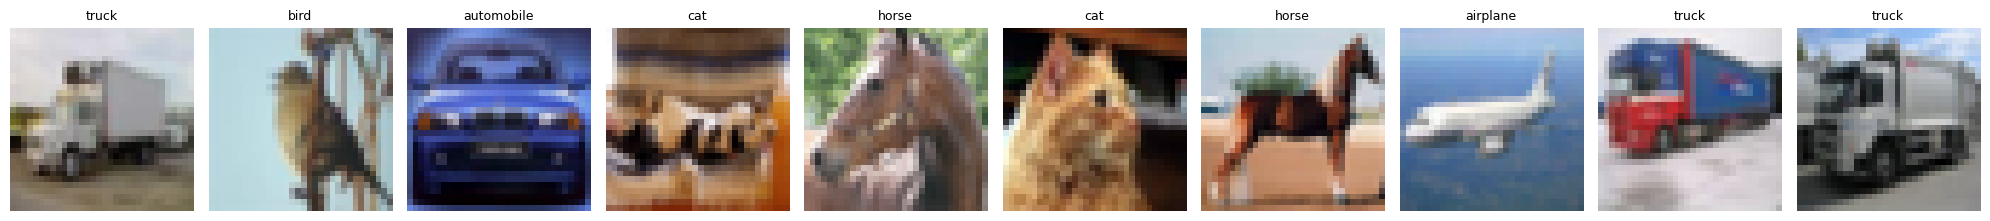

In [15]:
def denorm(tensor, mean=MEAN, std=STD):
    """Reverse normalisation for display."""
    t = tensor.clone().cpu()
    for c, (m, s) in enumerate(zip(mean, std)):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

def show_samples(dataset, n=10):
    fig, axs = plt.subplots(1, n, figsize=(n * 2, 2.5))
    indices = random.sample(range(len(dataset)), n)
    for ax, idx in zip(axs, indices):
        img, label = dataset[idx]
        ax.imshow(denorm(img).permute(1, 2, 0))
        ax.set_title(CLASS_NAMES[label], fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(testset)

# 3. Training infrastructure

We define helper functions **once** and reuse them across all architecture experiments.

In [16]:
def accuracy(y_pred, y):
    return y_pred.argmax(1).eq(y).float().mean()


def init_weights(m):
    """Kaiming for conv, Xavier for linear, ones/zeros for norms."""
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, (nn.BatchNorm2d, nn.LayerNorm)):
        nn.init.ones_(m.weight)
        nn.init.zeros_(m.bias)

In [17]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    loss_sum = acc_sum = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
        acc_sum  += accuracy(out, y).item()
    return loss_sum / len(loader), acc_sum / len(loader)


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    loss_sum = acc_sum = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out  = model(x)
        loss = criterion(out, y)
        loss_sum += loss.item()
        acc_sum  += accuracy(out, y).item()
    return loss_sum / len(loader), acc_sum / len(loader)

In [18]:
def fit(model, train_loader, val_loader, optimizer, criterion,
        epochs=20, scheduler=None, device='cpu',
        checkpoint='best_model.pt', verbose=True):
    """
    Full training loop. Returns history DataFrame.
    Saves best-val-loss checkpoint to `checkpoint`.
    """
    best_val_loss = float('inf')
    history = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc','lr','epoch_time']}

    for epoch in range(epochs):
        t0 = time.monotonic()
        tr_loss, tr_acc   = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = eval_epoch(model, val_loader,   criterion, device)
        if scheduler:
            scheduler.step()
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), checkpoint)
        elapsed = time.monotonic() - t0
        lr = optimizer.param_groups[0]['lr']
        for k, v in zip(history.keys(), [tr_loss, val_loss, tr_acc, val_acc, lr, elapsed]):
            history[k].append(v)
        if verbose and (epoch % 5 == 4 or epoch == 0):
            print(f'Epoch {epoch+1:02d}/{epochs} | {elapsed:.1f}s | LR {lr:.1e} | '
                  f'train {tr_loss:.3f}/{tr_acc:.3f} | val {val_loss:.3f}/{val_acc:.3f}'
                  + (' ★' if val_loss == best_val_loss else ''))
    return pd.DataFrame(history)


def plot_history(df, title=''):
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    axs[0].plot(df['train_loss'], label='train'); axs[0].plot(df['val_loss'], label='val')
    axs[0].set_title(f'{title} — loss'); axs[0].set_xlabel('epoch'); axs[0].legend(); axs[0].grid(alpha=.3)
    axs[1].plot(df['train_acc'],  label='train'); axs[1].plot(df['val_acc'],  label='val')
    axs[1].set_title(f'{title} — accuracy'); axs[1].set_xlabel('epoch'); axs[1].legend(); axs[1].grid(alpha=.3)
    axs[2].plot(df['lr']); axs[2].set_title('LR'); axs[2].set_yscale('log')
    axs[2].set_xlabel('epoch'); axs[2].grid(alpha=.3)
    plt.tight_layout(); plt.show()


def make_optimizer(model, lr=3e-4, wd=1e-4, epochs=20):
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    return opt, sched

In [19]:
# Comparison table — we will fill it after each experiment
results = []

def register_result(name, model, hist, ckpt):
    model.load_state_dict(torch.load(ckpt, map_location=device))
    _, test_acc = eval_epoch(model, testloader, nn.CrossEntropyLoss(), device)
    params = sum(p.numel() for p in model.parameters())
    results.append({
        'model': name,
        'params': f'{params:,}',
        'best_val_acc': f"{hist['val_acc'].max():.4f}",
        'test_acc': f'{test_acc:.4f}',
        'avg_s/epoch': f"{hist['epoch_time'].mean():.1f}s",
    })
    print(f'[{name}]  test_acc={test_acc:.4f}  params={params:,}')
    return test_acc

# 4. Baseline — LeNet

**LeNet-5** (LeCun, 1998) was the first CNN applied to real-world classification. Its structure is:

```
INPUT (3×32×32)
 → Conv(3→6, 5×5) → AvgPool(2×2)
 → Conv(6→16, 5×5) → AvgPool(2×2)
 → Flatten → FC(400→120) → FC(120→84) → FC(84→10)
```

Original activations: tanh. We use ReLU which is strictly better on modern hardware and with Kaiming initialisation.

> **Expected accuracy:** ~65–70 % on CIFAR-10 after 20 epochs. The network is too shallow and the 5×5 kernels lose spatial resolution quickly.

In [20]:
class LeNet(nn.Module):
    """Classic LeNet-5 adapted for 3×32×32 CIFAR-10 images."""

    def __init__(self, in_channels=3, n_classes=10):
        super().__init__()
        # ── Feature extractor ─────────────────────────────────────────────
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 6, kernel_size=5),          # → 6×28×28
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),             # → 6×14×14

            nn.Conv2d(6, 16, kernel_size=5),                   # → 16×10×10
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),             # → 16×5×5
        )
        # ── Classifier ────────────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# Quick sanity check
_x = torch.zeros(1, 3, 32, 32)
print(LeNet()(_x).shape)
summary(LeNet(), input_size=(1, 3, 32, 32), device='cpu')

torch.Size([1, 10])


Layer (type:depth-idx)                   Output Shape              Param #
LeNet                                    [1, 10]                   --
├─Sequential: 1-1                        [1, 16, 5, 5]             --
│    └─Conv2d: 2-1                       [1, 6, 28, 28]            456
│    └─ReLU: 2-2                         [1, 6, 28, 28]            --
│    └─AvgPool2d: 2-3                    [1, 6, 14, 14]            --
│    └─Conv2d: 2-4                       [1, 16, 10, 10]           2,416
│    └─ReLU: 2-5                         [1, 16, 10, 10]           --
│    └─AvgPool2d: 2-6                    [1, 16, 5, 5]             --
├─Sequential: 1-2                        [1, 10]                   --
│    └─Flatten: 2-7                      [1, 400]                  --
│    └─Linear: 2-8                       [1, 120]                  48,120
│    └─ReLU: 2-9                         [1, 120]                  --
│    └─Linear: 2-10                      [1, 84]                   10,164
│  

Epoch 01/20 | 20.1s | LR 3.0e-04 | train 2.011/0.267 | val 1.760/0.374 ★
Epoch 05/20 | 22.3s | LR 2.6e-04 | train 1.526/0.455 | val 1.412/0.489 ★
Epoch 10/20 | 23.5s | LR 1.5e-04 | train 1.415/0.495 | val 1.323/0.529 ★
Epoch 15/20 | 22.6s | LR 4.4e-05 | train 1.366/0.516 | val 1.278/0.538 ★
Epoch 20/20 | 22.1s | LR 0.0e+00 | train 1.353/0.520 | val 1.265/0.549 ★


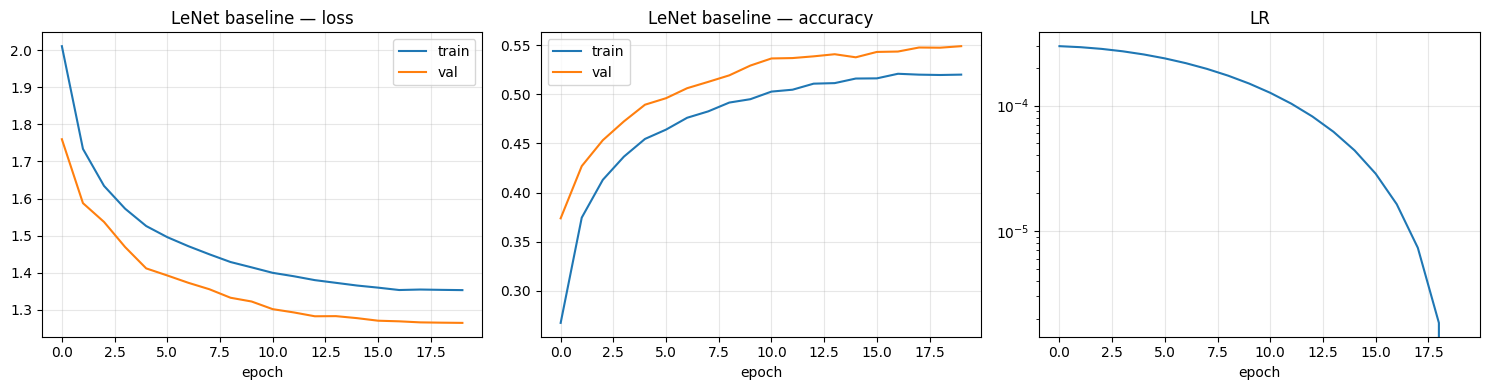

[LeNet]  test_acc=0.5550  params=62,006


0.5549841772151899

In [21]:
EPOCHS = 20

torch.manual_seed(SEED)
lenet = LeNet().to(device)
lenet.apply(init_weights)

opt, sched = make_optimizer(lenet, lr=3e-4, epochs=EPOCHS)
crit       = nn.CrossEntropyLoss()

hist_lenet = fit(lenet, trainloader, validloader, opt, crit,
                 epochs=EPOCHS, scheduler=sched, device=device,
                 checkpoint='ckpt_lenet.pt')

plot_history(hist_lenet, 'LeNet baseline')
register_result('LeNet', lenet, hist_lenet, 'ckpt_lenet.pt')

# 5. Improvement 1 — Batch Normalisation

**BatchNorm** (Ioffe & Szegedy, 2015) normalises each feature-map channel across the batch:
```
ŷ = (y − μ_B) / √(σ²_B + ε) * γ + β
```

**What it gives you:**
- Allows much higher learning rates → faster convergence.
- Acts as a regulariser → less overfitting.
- Makes the network much less sensitive to weight initialisation.

**Where to put it:** right after Conv, **before** the activation function (`Conv → BN → ReLU`).

Epoch 01/20 | 22.4s | LR 9.9e-04 | train 1.765/0.352 | val 1.507/0.448 ★
Epoch 05/20 | 26.1s | LR 8.5e-04 | train 1.347/0.517 | val 1.228/0.560 ★
Epoch 10/20 | 28.9s | LR 5.0e-04 | train 1.220/0.566 | val 1.124/0.601 ★
Epoch 15/20 | 30.1s | LR 1.5e-04 | train 1.145/0.593 | val 1.055/0.630 ★
Epoch 20/20 | 31.0s | LR 0.0e+00 | train 1.121/0.602 | val 1.040/0.634 ★


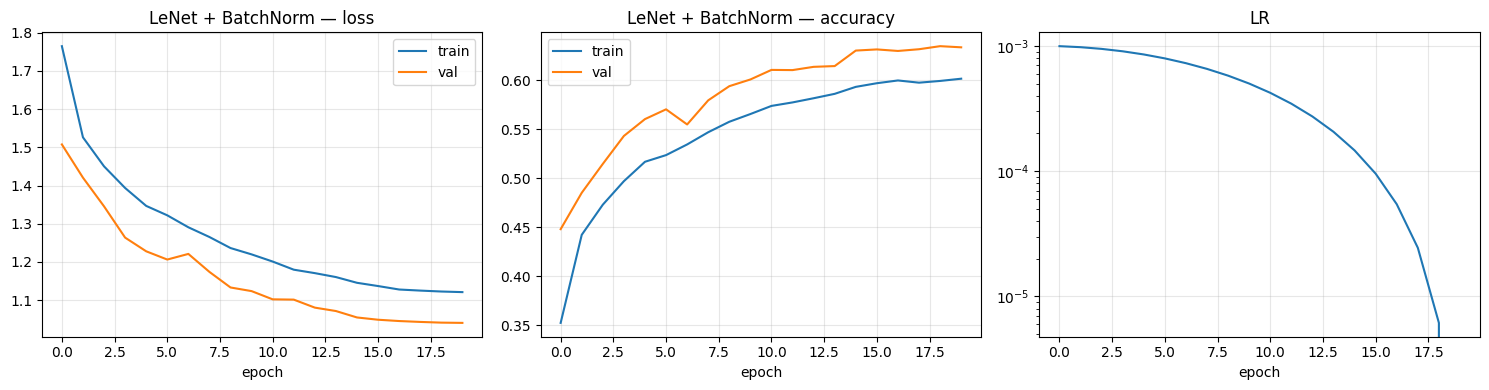

[LeNet+BN]  test_acc=0.6263  params=62,050


0.6262856012658228

In [22]:
class LeNetBN(nn.Module):
    """LeNet + BatchNorm after every Conv."""

    def __init__(self, in_channels=3, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 6, 5),
            nn.BatchNorm2d(6),                 # ← NEW
            nn.ReLU(),
            nn.AvgPool2d(2, 2),

            nn.Conv2d(6, 16, 5),
            nn.BatchNorm2d(16),                # ← NEW
            nn.ReLU(),
            nn.AvgPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120), nn.ReLU(),
            nn.Linear(120, 84),         nn.ReLU(),
            nn.Linear(84, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


torch.manual_seed(SEED)
lenet_bn = LeNetBN().to(device)
lenet_bn.apply(init_weights)

# With BN we can push the LR higher
opt, sched = make_optimizer(lenet_bn, lr=1e-3, epochs=EPOCHS)
hist_bn = fit(lenet_bn, trainloader, validloader, opt, crit,
              epochs=EPOCHS, scheduler=sched, device=device,
              checkpoint='ckpt_lenet_bn.pt')

plot_history(hist_bn, 'LeNet + BatchNorm')
register_result('LeNet+BN', lenet_bn, hist_bn, 'ckpt_lenet_bn.pt')

# 6. Improvement 2 — Strided convolution + deeper network

**Replace max-pooling with a strided convolution** (stride=2 instead of pool).

Why: pooling throws away information by taking the max (or average) of a 2×2 block. A Conv with stride=2 **learns** how to downsample — at the cost of a few more parameters.

We also deepen the network: 4 conv layers instead of 2, narrower kernels (3×3), more channels.

```
INPUT
 → Conv(3→32, 3×3, pad=1) → BN → ReLU
 → Conv(32→32, 3×3, pad=1, stride=2) → BN → ReLU   ← downsamples 32→16
 → Conv(32→64, 3×3, pad=1) → BN → ReLU
 → Conv(64→64, 3×3, pad=1, stride=2) → BN → ReLU   ← downsamples 16→8
 → GAP → FC(64→10)
```

In [23]:
class DeepStridedNet(nn.Module):
    """
    Deeper network with strided conv for downsampling (no pooling layer).
    Follows the modern preference for 3×3 kernels over 5×5.
    """

    def __init__(self, in_channels=3, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 32×32 → 16×16
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1, stride=2),   # ← strided
            nn.BatchNorm2d(32), nn.ReLU(),

            # Block 2: 16×16 → 8×8
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1, stride=2),   # ← strided
            nn.BatchNorm2d(64), nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                           # 64×8×8 = 4096
            nn.Linear(64 * 8 * 8, 256), nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


summary(DeepStridedNet(), (1, 3, 32, 32), device='cpu')

Layer (type:depth-idx)                   Output Shape              Param #
DeepStridedNet                           [1, 10]                   --
├─Sequential: 1-1                        [1, 64, 8, 8]             --
│    └─Conv2d: 2-1                       [1, 32, 32, 32]           896
│    └─BatchNorm2d: 2-2                  [1, 32, 32, 32]           64
│    └─ReLU: 2-3                         [1, 32, 32, 32]           --
│    └─Conv2d: 2-4                       [1, 32, 16, 16]           9,248
│    └─BatchNorm2d: 2-5                  [1, 32, 16, 16]           64
│    └─ReLU: 2-6                         [1, 32, 16, 16]           --
│    └─Conv2d: 2-7                       [1, 64, 16, 16]           18,496
│    └─BatchNorm2d: 2-8                  [1, 64, 16, 16]           128
│    └─ReLU: 2-9                         [1, 64, 16, 16]           --
│    └─Conv2d: 2-10                      [1, 64, 8, 8]             36,928
│    └─BatchNorm2d: 2-11                 [1, 64, 8, 8]             128
│

Epoch 01/20 | 36.5s | LR 9.9e-04 | train 1.778/0.341 | val 1.412/0.492 ★
Epoch 05/20 | 34.1s | LR 8.5e-04 | train 1.166/0.581 | val 0.922/0.669 ★
Epoch 10/20 | 34.1s | LR 5.0e-04 | train 0.948/0.667 | val 0.743/0.737 ★
Epoch 15/20 | 29.2s | LR 1.5e-04 | train 0.838/0.706 | val 0.670/0.765 ★
Epoch 20/20 | 32.3s | LR 0.0e+00 | train 0.803/0.722 | val 0.642/0.774


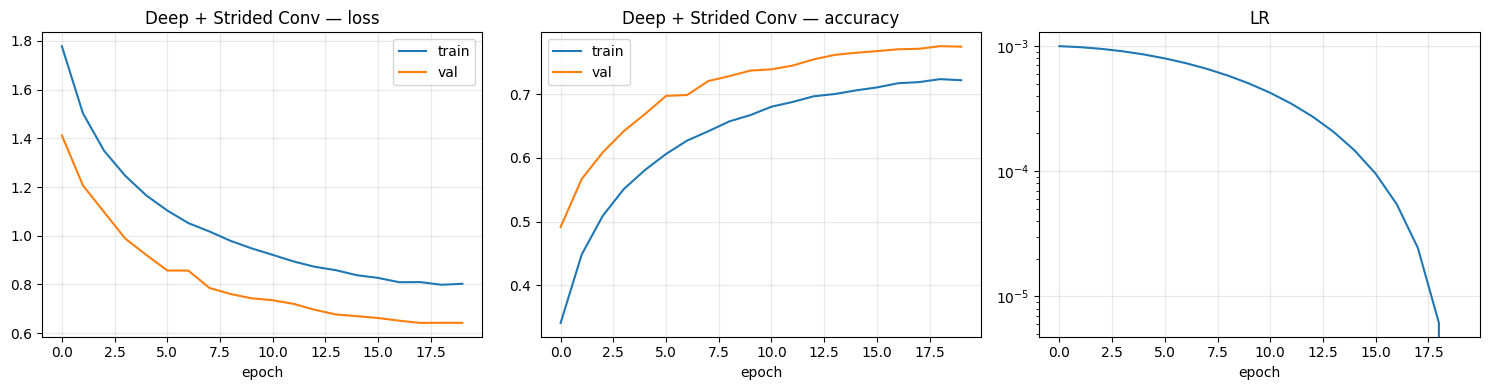

[Deep+Strided]  test_acc=0.7707  params=1,117,354


0.7706685126582279

In [24]:
torch.manual_seed(SEED)
deep_net = DeepStridedNet().to(device)
deep_net.apply(init_weights)

opt, sched = make_optimizer(deep_net, lr=1e-3, epochs=EPOCHS)
hist_deep = fit(deep_net, trainloader, validloader, opt, crit,
                epochs=EPOCHS, scheduler=sched, device=device,
                checkpoint='ckpt_deep.pt')

plot_history(hist_deep, 'Deep + Strided Conv')
register_result('Deep+Strided', deep_net, hist_deep, 'ckpt_deep.pt')

# 7. Improvement 3 — Global Average Pooling (GAP)

The huge `Flatten → FC` head is the biggest source of parameters in LeNet. A `16×5×5 = 400` → `120` linear layer alone has 48,120 parameters.

**GAP** (Lin et al., 2013) replaces the entire head with a single spatial average per channel:
```
tensor (C×H×W) → AdaptiveAvgPool2d(1) → (C×1×1) → Flatten → FC(C, n_classes)
```

**Benefits:**
- Drastically fewer parameters → less overfitting.
- Built-in spatial invariance — the network can generalise to different crop sizes.
- Makes Grad-CAM trivial (the feature maps before GAP ARE the class activation maps).

In [25]:
class DeepGAPNet(nn.Module):
    """Deep strided network with GAP instead of Flatten+FC."""

    def __init__(self, in_channels=3, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1, stride=2),
            nn.BatchNorm2d(32), nn.ReLU(),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1, stride=2),
            nn.BatchNorm2d(64), nn.ReLU(),

            nn.Conv2d(64, 128, 3, padding=1),       # extra capacity
            nn.BatchNorm2d(128), nn.ReLU(),
        )
        self.gap        = nn.AdaptiveAvgPool2d(1)    # ← GAP
        self.classifier = nn.Linear(128, n_classes)  # tiny head

    def forward(self, x):
        f = self.features(x)          # (B, 128, H, W)
        g = self.gap(f).flatten(1)    # (B, 128)
        return self.classifier(g)


summary(DeepGAPNet(), (1, 3, 32, 32), device='cpu')

Layer (type:depth-idx)                   Output Shape              Param #
DeepGAPNet                               [1, 10]                   --
├─Sequential: 1-1                        [1, 128, 8, 8]            --
│    └─Conv2d: 2-1                       [1, 32, 32, 32]           896
│    └─BatchNorm2d: 2-2                  [1, 32, 32, 32]           64
│    └─ReLU: 2-3                         [1, 32, 32, 32]           --
│    └─Conv2d: 2-4                       [1, 32, 16, 16]           9,248
│    └─BatchNorm2d: 2-5                  [1, 32, 16, 16]           64
│    └─ReLU: 2-6                         [1, 32, 16, 16]           --
│    └─Conv2d: 2-7                       [1, 64, 16, 16]           18,496
│    └─BatchNorm2d: 2-8                  [1, 64, 16, 16]           128
│    └─ReLU: 2-9                         [1, 64, 16, 16]           --
│    └─Conv2d: 2-10                      [1, 64, 8, 8]             36,928
│    └─BatchNorm2d: 2-11                 [1, 64, 8, 8]             128
│

Epoch 01/20 | 33.2s | LR 9.9e-04 | train 1.586/0.414 | val 1.326/0.533 ★
Epoch 05/20 | 29.9s | LR 8.5e-04 | train 0.935/0.670 | val 0.978/0.659 ★
Epoch 10/20 | 27.9s | LR 5.0e-04 | train 0.732/0.745 | val 0.725/0.741 ★
Epoch 15/20 | 24.7s | LR 1.5e-04 | train 0.636/0.779 | val 0.643/0.773 ★
Epoch 20/20 | 24.4s | LR 0.0e+00 | train 0.602/0.793 | val 0.617/0.782


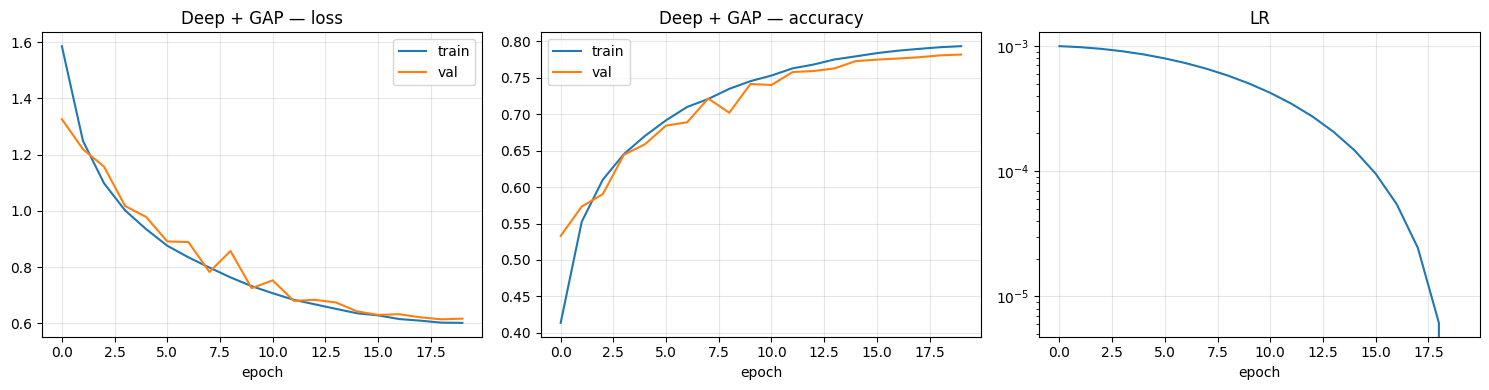

[Deep+GAP]  test_acc=0.7879  params=141,354


0.7878757911392406

In [26]:
torch.manual_seed(SEED)
gap_net = DeepGAPNet().to(device)
gap_net.apply(init_weights)

opt, sched = make_optimizer(gap_net, lr=1e-3, epochs=EPOCHS)
hist_gap = fit(gap_net, trainloader, validloader, opt, crit,
               epochs=EPOCHS, scheduler=sched, device=device,
               checkpoint='ckpt_gap.pt')

plot_history(hist_gap, 'Deep + GAP')
register_result('Deep+GAP', gap_net, hist_gap, 'ckpt_gap.pt')

# 8. Improvement 4 — Cascaded (factorised) convolutions

A single 5×5 convolution has receptive field 5×5 and costs `5×5×C_in×C_out` multiplications per position.

Two **cascaded** 3×3 convolutions have the **same receptive field** (5×5) but only `2 × 3×3×C = 18C` multiplications — and two non-linearities instead of one.

```
Conv(5×5, C) ≡ Conv(3×3) → ReLU → Conv(3×3)   (same RF, ~44% fewer params)
```

We build a reusable `CascadedConvBlock`:

In [27]:
class CascadedConvBlock(nn.Module):
    """
    Two 3×3 convolutions with the same receptive field as one 5×5.
    Optional channel expansion between the two convs.
    """
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        mid_ch = max(in_ch, out_ch)
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  mid_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(mid_ch), nn.ReLU(inplace=True),
            nn.Conv2d(mid_ch, out_ch, 3, padding=1, stride=stride, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class CascadedNet(nn.Module):
    def __init__(self, in_channels=3, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            CascadedConvBlock(in_channels, 32, stride=1),
            CascadedConvBlock(32, 64,  stride=2),   # 32×32 → 16×16
            CascadedConvBlock(64, 128, stride=2),   # 16×16 → 8×8
        )
        self.gap        = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(128, n_classes)

    def forward(self, x):
        return self.classifier(self.gap(self.features(x)).flatten(1))


summary(CascadedNet(), (1, 3, 32, 32), device='cpu')

Layer (type:depth-idx)                   Output Shape              Param #
CascadedNet                              [1, 10]                   --
├─Sequential: 1-1                        [1, 128, 8, 8]            --
│    └─CascadedConvBlock: 2-1            [1, 32, 32, 32]           --
│    │    └─Sequential: 3-1              [1, 32, 32, 32]           10,208
│    └─CascadedConvBlock: 2-2            [1, 64, 16, 16]           --
│    │    └─Sequential: 3-2              [1, 64, 16, 16]           55,552
│    └─CascadedConvBlock: 2-3            [1, 128, 8, 8]            --
│    │    └─Sequential: 3-3              [1, 128, 8, 8]            221,696
├─AdaptiveAvgPool2d: 1-2                 [1, 128, 1, 1]            --
├─Linear: 1-3                            [1, 10]                   1,290
Total params: 288,746
Trainable params: 288,746
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 66.95
Input size (MB): 0.01
Forward/backward pass size (MB): 3.01
Params size (MB): 1.15
Estimated Tot

Epoch 01/20 | 51.8s | LR 9.9e-04 | train 1.531/0.436 | val 1.400/0.486 ★
Epoch 05/20 | 52.5s | LR 8.5e-04 | train 0.823/0.713 | val 0.913/0.694 ★
Epoch 10/20 | 52.1s | LR 5.0e-04 | train 0.604/0.791 | val 0.651/0.771 ★
Epoch 15/20 | 51.5s | LR 1.5e-04 | train 0.495/0.829 | val 0.542/0.816 ★
Epoch 20/20 | 52.2s | LR 0.0e+00 | train 0.450/0.845 | val 0.486/0.832 ★


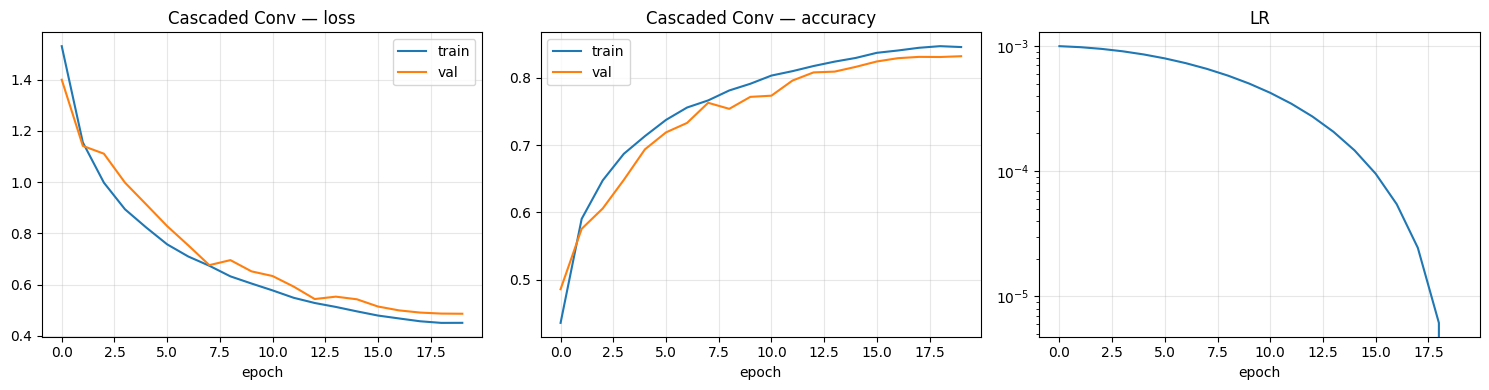

[Cascaded]  test_acc=0.8222  params=288,746


0.8221914556962026

In [28]:
torch.manual_seed(SEED)
casc_net = CascadedNet().to(device)
casc_net.apply(init_weights)

opt, sched = make_optimizer(casc_net, lr=1e-3, epochs=EPOCHS)
hist_casc = fit(casc_net, trainloader, validloader, opt, crit,
                epochs=EPOCHS, scheduler=sched, device=device,
                checkpoint='ckpt_casc.pt')

plot_history(hist_casc, 'Cascaded Conv')
register_result('Cascaded', casc_net, hist_casc, 'ckpt_casc.pt')

# 9. Improvement 5 — Depthwise Separable Convolution

**Idea (Howard et al., MobileNets, 2017):** factor a standard Conv into two cheaper steps:

1. **Depthwise conv** — one filter per input channel (`groups=C_in`): captures spatial features independently per channel.
2. **Pointwise conv** — `1×1` conv: mixes channels.

**Parameter cost:**
```
Standard  : k² × C_in × C_out
Depthwise : k² × C_in   +   C_in × C_out  (1×1)
Reduction : ≈ 8–9× for k=3
```

This makes the same architecture **8–9× smaller** with only a small accuracy drop — or allows you to **make it wider** for the same budget.

In [29]:
class DepthwiseSeparableConv(nn.Module):
    """Depthwise + Pointwise conv with BN and ReLU."""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.dw = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, 3, padding=1, stride=stride,
                      groups=in_ch, bias=False),      # ← depthwise
            nn.BatchNorm2d(in_ch), nn.ReLU(inplace=True),
        )
        self.pw = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),  # ← pointwise
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.pw(self.dw(x))


class DepthwiseNet(nn.Module):
    def __init__(self, in_channels=3, n_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
        )
        self.features = nn.Sequential(
            DepthwiseSeparableConv(32, 64,  stride=2),  # 32→16
            DepthwiseSeparableConv(64, 128, stride=2),  # 16→8
            DepthwiseSeparableConv(128, 128),
            DepthwiseSeparableConv(128, 256, stride=2), # 8→4
        )
        self.gap        = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(256, n_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.features(x)
        return self.classifier(self.gap(x).flatten(1))


summary(DepthwiseNet(), (1, 3, 32, 32), device='cpu')

Layer (type:depth-idx)                   Output Shape              Param #
DepthwiseNet                             [1, 10]                   --
├─Sequential: 1-1                        [1, 32, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 32, 32, 32]           864
│    └─BatchNorm2d: 2-2                  [1, 32, 32, 32]           64
│    └─ReLU: 2-3                         [1, 32, 32, 32]           --
├─Sequential: 1-2                        [1, 256, 4, 4]            --
│    └─DepthwiseSeparableConv: 2-4       [1, 64, 16, 16]           --
│    │    └─Sequential: 3-1              [1, 32, 16, 16]           352
│    │    └─Sequential: 3-2              [1, 64, 16, 16]           2,176
│    └─DepthwiseSeparableConv: 2-5       [1, 128, 8, 8]            --
│    │    └─Sequential: 3-3              [1, 64, 8, 8]             704
│    │    └─Sequential: 3-4              [1, 128, 8, 8]            8,448
│    └─DepthwiseSeparableConv: 2-6       [1, 128, 8, 8]            --
│    │

Epoch 01/20 | 24.4s | LR 9.9e-04 | train 1.781/0.336 | val 1.523/0.440 ★
Epoch 05/20 | 24.7s | LR 8.5e-04 | train 1.197/0.570 | val 1.133/0.596 ★
Epoch 10/20 | 24.9s | LR 5.0e-04 | train 0.975/0.655 | val 0.948/0.658 ★
Epoch 15/20 | 25.3s | LR 1.5e-04 | train 0.895/0.681 | val 0.869/0.692 ★
Epoch 20/20 | 24.0s | LR 0.0e+00 | train 0.871/0.693 | val 0.854/0.693 ★


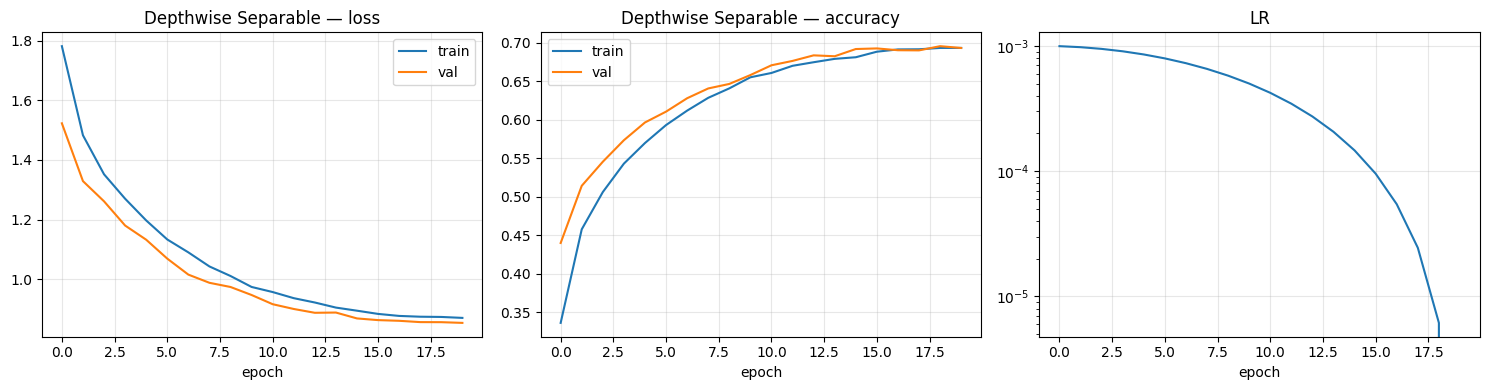

[DW-Separable]  test_acc=0.6970  params=67,914


0.696993670886076

In [30]:
torch.manual_seed(SEED)
dw_net = DepthwiseNet().to(device)
dw_net.apply(init_weights)

opt, sched = make_optimizer(dw_net, lr=1e-3, epochs=EPOCHS)
hist_dw = fit(dw_net, trainloader, validloader, opt, crit,
              epochs=EPOCHS, scheduler=sched, device=device,
              checkpoint='ckpt_dw.pt')

plot_history(hist_dw, 'Depthwise Separable')
register_result('DW-Separable', dw_net, hist_dw, 'ckpt_dw.pt')

# 10. Improvement 6 — Residual connections

**ResNet** (He et al., 2015) adds a **skip connection** that bypasses one or two conv layers:
```
y = F(x) + x          (identity shortcut)
y = F(x) + W·x        (projection shortcut, used when channels change)
```

**Why it helps:**
- Gradients flow directly to earlier layers → no vanishing gradient.
- The network learns **residuals** (corrections) rather than full transformations → easier optimisation.
- Enables going much deeper (50, 100, 152 layers) without degradation.

In [31]:
class ResidualBlock(nn.Module):
    """
    Pre-activation residual block (He et al., 2016).
    BN → ReLU → Conv → BN → ReLU → Conv → +skip
    Projection shortcut when in_ch ≠ out_ch or stride > 1.
    """
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm2d(in_ch),  nn.ReLU(inplace=True),
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, stride=stride, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
        )
        # Shortcut: match dimensions if needed
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        return self.block(x) + self.shortcut(x)


class TinyResNet(nn.Module):
    def __init__(self, in_channels=3, n_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
        )
        self.layer1 = ResidualBlock(32,  64,  stride=2)   # 32→16
        self.layer2 = ResidualBlock(64,  128, stride=2)   # 16→8
        self.layer3 = ResidualBlock(128, 256, stride=2)   # 8→4
        self.gap        = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(256, n_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return self.classifier(self.gap(x).flatten(1))


summary(TinyResNet(), (1, 3, 32, 32), device='cpu')

Layer (type:depth-idx)                   Output Shape              Param #
TinyResNet                               [1, 10]                   --
├─Sequential: 1-1                        [1, 32, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 32, 32, 32]           864
│    └─BatchNorm2d: 2-2                  [1, 32, 32, 32]           64
│    └─ReLU: 2-3                         [1, 32, 32, 32]           --
├─ResidualBlock: 1-2                     [1, 64, 16, 16]           --
│    └─Sequential: 2-4                   [1, 64, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 32, 32, 32]           64
│    │    └─ReLU: 3-2                    [1, 32, 32, 32]           --
│    │    └─Conv2d: 3-3                  [1, 64, 16, 16]           18,432
│    │    └─BatchNorm2d: 3-4             [1, 64, 16, 16]           128
│    │    └─ReLU: 3-5                    [1, 64, 16, 16]           --
│    │    └─Conv2d: 3-6                  [1, 64, 16, 16]           36,864
│    

In [ ]:
torch.manual_seed(SEED)
resnet = TinyResNet().to(device)
resnet.apply(init_weights)

opt, sched = make_optimizer(resnet, lr=1e-3, epochs=EPOCHS)
hist_res = fit(resnet, trainloader, validloader, opt, crit,
               epochs=EPOCHS, scheduler=sched, device=device,
               checkpoint='ckpt_resnet.pt')

plot_history(hist_res, 'TinyResNet')
register_result('TinyResNet', resnet, hist_res, 'ckpt_resnet.pt')

Epoch 01/20 | 40.6s | LR 9.9e-04 | train 1.686/0.398 | val 1.291/0.537 ★


# 11. Improvement 7 — Squeeze-and-Excitation (SE) block

**SE-Net** (Hu et al., 2018, CVPR Best Paper) adds a **channel attention** mechanism:
```
x (C×H×W)
 → GAP → (C,)               ← "Squeeze": summarise each channel globally
 → FC(C→C/r) → ReLU
 → FC(C/r→C) → Sigmoid       ← "Excitation": learn per-channel importance weights
 → x * scale                 ← re-scale feature maps
```

The SE block is a **plug-in module** — you can add it after any convolutional block for 0.2–1% extra accuracy at almost no extra cost (r=16 is standard).

In [ ]:
class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, max(channels // reduction, 4)),
            nn.ReLU(inplace=True),
            nn.Linear(max(channels // reduction, 4), channels),
            nn.Sigmoid(),
        )

    def forward(self, x):
        scale = self.se(x).view(x.size(0), x.size(1), 1, 1)
        return x * scale


class SEResidualBlock(nn.Module):
    """Residual block + SE attention."""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm2d(in_ch),  nn.ReLU(inplace=True),
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, stride=stride, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
        )
        self.se       = SEBlock(out_ch)                             # ← NEW
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        return self.se(self.block(x)) + self.shortcut(x)


class TinySEResNet(nn.Module):
    def __init__(self, in_channels=3, n_classes=10):
        super().__init__()
        self.stem   = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
        )
        self.layers = nn.Sequential(
            SEResidualBlock(32,  64,  stride=2),
            SEResidualBlock(64,  128, stride=2),
            SEResidualBlock(128, 256, stride=2),
        )
        self.gap        = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(256, n_classes)

    def forward(self, x):
        return self.classifier(self.gap(self.layers(self.stem(x))).flatten(1))


summary(TinySEResNet(), (1, 3, 32, 32), device='cpu')

In [ ]:
torch.manual_seed(SEED)
se_resnet = TinySEResNet().to(device)
se_resnet.apply(init_weights)

opt, sched = make_optimizer(se_resnet, lr=1e-3, epochs=EPOCHS)
hist_se = fit(se_resnet, trainloader, validloader, opt, crit,
              epochs=EPOCHS, scheduler=sched, device=device,
              checkpoint='ckpt_se.pt')

plot_history(hist_se, 'SE-ResNet')
register_result('SE-ResNet', se_resnet, hist_se, 'ckpt_se.pt')

# 12. Architecture comparison

All models, same dataset, same seed, same number of epochs.

In [ ]:
summary_df = pd.DataFrame(results)
print(summary_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
accs = [float(r['test_acc']) for r in results]
names = [r['model'] for r in results]
bars = ax.bar(names, accs, color=plt.cm.viridis(np.linspace(0.2, 0.8, len(names))))
ax.set_ylabel('Test accuracy')
ax.set_title('Test accuracy by architecture')
ax.set_ylim(min(accs) - 0.05, 1.0)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=9)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 13. Data-centric analysis

> **The data-centric view:** instead of just tuning the model, understand *what* the model gets wrong, *why*, and whether the root cause is in the data or the architecture.

We use the best model (SE-ResNet) for all analysis below.

In [ ]:
# Load best checkpoint
best_model = TinySEResNet().to(device)
best_model.load_state_dict(torch.load('ckpt_se.pt', map_location=device))
best_model.eval()
print('Loaded SE-ResNet best checkpoint')

## 13.1 Confusion matrix — which classes are confused?

The confusion matrix shows, for every true class (row), how often each predicted class (column) was chosen. Off-diagonal cells reveal **systematic confusions** — these are the dataset pairs worth investigating.

In [ ]:
@torch.no_grad()
def get_all_predictions(model, loader, device):
    all_labels, all_preds, all_probs, all_imgs = [], [], [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        probs  = torch.softmax(logits, dim=1)
        preds  = logits.argmax(1)
        all_labels.append(y.cpu())
        all_preds.append(preds.cpu())
        all_probs.append(probs.cpu())
        all_imgs.append(x.cpu())
    return (torch.cat(all_labels), torch.cat(all_preds),
            torch.cat(all_probs), torch.cat(all_imgs))


labels, preds, probs, imgs = get_all_predictions(best_model, testloader, device)
test_acc_final = (labels == preds).float().mean().item()
print(f'Test accuracy: {test_acc_final:.4f}')

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(labels.numpy(), preds.numpy())
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp.plot(values_format='d', cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Confusion matrix — SE-ResNet on test set', fontsize=13)
plt.tight_layout()
plt.show()

# Most confused pairs
import itertools
pairs = [(cm[i,j], CLASS_NAMES[i], CLASS_NAMES[j])
         for i,j in itertools.product(range(N_CLASSES), range(N_CLASSES)) if i != j]
pairs.sort(reverse=True)
print('\nTop-5 confusion pairs:')
for cnt, true_cls, pred_cls in pairs[:5]:
    print(f'  {true_cls:12s} → predicted as {pred_cls:12s}: {cnt} times')

## 13.2 Per-class accuracy

Some classes are inherently harder (e.g. cat vs. dog) — the model should know which ones.

In [ ]:
per_class_acc = {}
for c in range(N_CLASSES):
    mask = (labels == c)
    per_class_acc[CLASS_NAMES[c]] = (preds[mask] == labels[mask]).float().mean().item()

fig, ax = plt.subplots(figsize=(10, 4))
sorted_classes = sorted(per_class_acc.items(), key=lambda x: x[1])
cls_names = [k for k, _ in sorted_classes]
cls_accs  = [v for _, v in sorted_classes]
colors = ['#d62728' if v < 0.7 else '#2ca02c' for v in cls_accs]
ax.barh(cls_names, cls_accs, color=colors)
ax.axvline(test_acc_final, color='black', linestyle='--', label=f'mean={test_acc_final:.3f}')
ax.set_xlabel('Accuracy')
ax.set_title('Per-class accuracy')
ax.legend(); ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 13.3 Hard samples — what does the model get wrong?

We find the test images with the **highest loss** (model was most confident and wrong) and the **lowest confidence on correct predictions** (borderline correct).

In [ ]:
criterion_none = nn.CrossEntropyLoss(reduction='none')

@torch.no_grad()
def get_per_sample_loss(model, loader, device):
    all_loss, all_labels, all_preds, all_imgs = [], [], [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out  = model(x)
        loss = criterion_none(out, y)
        all_loss.append(loss.cpu())
        all_labels.append(y.cpu())
        all_preds.append(out.argmax(1).cpu())
        all_imgs.append(x.cpu())
    return (torch.cat(all_loss), torch.cat(all_labels),
            torch.cat(all_preds), torch.cat(all_imgs))


sample_loss, sample_labels, sample_preds, sample_imgs = get_per_sample_loss(
    best_model, testloader, device)

# ── Top-N wrong predictions with highest loss ─────────────────────────────
def show_hard_samples(title, indices, n=10):
    fig, axs = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle(title, fontsize=13)
    for ax, idx in zip(axs.flat, indices[:n]):
        ax.imshow(denorm(sample_imgs[idx]).permute(1, 2, 0))
        color = 'red' if sample_labels[idx] != sample_preds[idx] else 'green'
        ax.set_title(f'true: {CLASS_NAMES[sample_labels[idx]]}\n'
                     f'pred: {CLASS_NAMES[sample_preds[idx]]}\n'
                     f'loss: {sample_loss[idx]:.2f}',
                     color=color, fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

wrong_mask   = (sample_labels != sample_preds)
wrong_losses = sample_loss.clone()
wrong_losses[~wrong_mask] = -1.0
top_wrong    = wrong_losses.argsort(descending=True)

show_hard_samples('Hardest wrong predictions (highest loss)', top_wrong)

In [ ]:
# ── Borderline correct: right answer but low confidence ──────────────────
correct_mask    = (sample_labels == sample_preds)
confidence      = probs[torch.arange(len(probs)), sample_labels]
border_conf     = confidence.clone()
border_conf[~correct_mask] = 1.0
border_correct  = border_conf.argsort()

show_hard_samples('Borderline correct (lowest confidence, right answer)', border_correct)

### Patterns to look for in hard samples

| Pattern | Root cause | Fix |
|---|---|---|
| Image is cropped / partially visible | Dataset collection issue | More diverse augmentation |
| Unusual lighting / background | Domain mismatch | Color augmentation, more data |
| Ambiguous object (cat that looks like dog) | Label noise | Clean labels |
| Multiple objects in frame | Multi-label task | Change loss |
| Image is clearly from a different distribution | OOD sample | Filter or separate model |

# 14. What does the network look at? — Grad-CAM

**Gradient-weighted Class Activation Maps** (Selvaraju et al., 2017) visualise which spatial regions the network uses for its decision.

**Algorithm:**
1. Pick a target class `c` and a target convolutional layer.
2. Forward pass → compute logit for class `c`.
3. Backpropagate to the target layer → gradients `∂y_c / ∂A_k` for each channel `k`.
4. Pool gradients spatially: `α_k = GAP(∂y_c / ∂A_k)`.
5. Weighted sum of activation maps: `L_Grad-CAM = ReLU(Σ_k α_k · A_k)`.
6. Upsample to input size and overlay as a heatmap.

**Why is this important?**
- A model can achieve high accuracy **for the wrong reason** (e.g. looking at the background).
- Grad-CAM reveals these shortcuts — which you can fix with cropping, masking, or targeted augmentation.

In [ ]:
class GradCAM:
    """Grad-CAM for any model. Attach to a target layer by name."""

    def __init__(self, model, target_layer: nn.Module):
        self.model = model
        self.activations = None
        self.gradients   = None
        self._fwd_hook = target_layer.register_forward_hook(self._save_activation)
        self._bwd_hook = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def __call__(self, x, class_idx=None):
        """
        Returns cam (H, W) numpy array in [0, 1].
        If class_idx is None, uses argmax of logits.
        """
        self.model.eval()
        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(1).item()

        self.model.zero_grad()
        logits[0, class_idx].backward()

        # α_k = mean over spatial dims of |∂y_c / ∂A_k|
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # (1,C,1,1)
        cam = (weights * self.activations).sum(dim=1).squeeze()  # (H,W)
        cam = F.relu(cam)
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam.cpu().numpy(), class_idx

    def remove(self):
        self._fwd_hook.remove()
        self._bwd_hook.remove()


# Attach to the last conv layer of SE-ResNet
# (the last SEResidualBlock's inner Conv, before GAP)
target_layer = list(best_model.layers[-1].block.children())[-1]
gradcam = GradCAM(best_model, target_layer)
print(f'Grad-CAM attached to: {target_layer}')

In [ ]:
import matplotlib.cm as mpl_cm

def show_gradcam(images_tensor, labels_tensor, n=8, alpha=0.5):
    """
    Display Grad-CAM heatmaps overlaid on input images.
    images_tensor: (N, C, H, W) CPU tensor (normalised)
    """
    fig, axs = plt.subplots(2, n, figsize=(n * 2.5, 5))
    indices  = random.sample(range(len(images_tensor)), n)

    for col, idx in enumerate(indices):
        x = images_tensor[idx].unsqueeze(0).to(device)
        cam, pred_idx = gradcam(x)

        img_show = denorm(images_tensor[idx]).permute(1, 2, 0).numpy()
        true_cls = CLASS_NAMES[labels_tensor[idx].item()]
        pred_cls = CLASS_NAMES[pred_idx]

        # ── top row: original ─────────────────────────────────────────────
        axs[0, col].imshow(img_show)
        color = 'green' if true_cls == pred_cls else 'red'
        axs[0, col].set_title(f't:{true_cls}\np:{pred_cls}', color=color, fontsize=8)
        axs[0, col].axis('off')

        # ── bottom row: heatmap overlay ────────────────────────────────────
        cam_up = F.interpolate(
            torch.tensor(cam).unsqueeze(0).unsqueeze(0).float(),
            size=(32, 32), mode='bilinear', align_corners=False
        ).squeeze().numpy()
        heatmap = mpl_cm.jet(cam_up)[:, :, :3]   # (H,W,3), no alpha
        overlay = (1 - alpha) * img_show + alpha * heatmap
        overlay = np.clip(overlay, 0, 1)
        axs[1, col].imshow(overlay)
        axs[1, col].axis('off')

    axs[0, 0].set_ylabel('Input', fontsize=9)
    axs[1, 0].set_ylabel('Grad-CAM', fontsize=9)
    plt.suptitle('Grad-CAM: what the network looks at (red = most important)', fontsize=12)
    plt.tight_layout()
    plt.show()


# Show on random test samples
show_gradcam(sample_imgs, sample_labels, n=8)

In [ ]:
# ── Compare: correct vs. wrong predictions ────────────────────────────────
print('Grad-CAM on CORRECTLY classified samples:')
correct_ids = (sample_labels == sample_preds).nonzero(as_tuple=True)[0]
show_gradcam(sample_imgs[correct_ids], sample_labels[correct_ids], n=8)

print('\nGrad-CAM on INCORRECTLY classified samples:')
wrong_ids = (sample_labels != sample_preds).nonzero(as_tuple=True)[0]
if len(wrong_ids) >= 8:
    show_gradcam(sample_imgs[wrong_ids], sample_labels[wrong_ids], n=8)

### How to read Grad-CAM

| What you see | Interpretation |
|---|---|
| Heatmap on the object | ✅ Network uses the right features |
| Heatmap on the background | ⚠️ Network uses background bias (e.g. *ships always appear on water*) |
| Heatmap spread everywhere | ⚠️ Network is uncertain |
| Heatmap on a texture patch | ⚠️ Texture bias — may fail on novel backgrounds |
| Heatmap shifts between correct/wrong | 🔍 Class boundary confusion — need more discriminative features |

# 15. Filter and activation visualisation

**First-layer filters** tell you what low-level patterns the network responds to.
In supervised networks: blobs, edges at various orientations and frequencies.
In well-trained networks the filters look structured; in untrained ones they look random.

In [ ]:
def show_conv_filters(model, layer_name='stem', n_filters=16):
    """Visualise learned first-layer conv filters (one colour image per filter)."""
    stem_conv = None
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            stem_conv = module
            break
    if stem_conv is None:
        print('No Conv2d found'); return

    filters = stem_conv.weight.data.cpu()   # (out_ch, in_ch, kH, kW)
    n = min(n_filters, filters.shape[0])
    cols = 8
    rows = (n + cols - 1) // cols
    fig, axs = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.5))
    axs = axs.flat
    for i in range(n):
        f = filters[i].permute(1, 2, 0).numpy()   # (kH, kW, 3)
        f = (f - f.min()) / (f.max() - f.min() + 1e-8)
        if f.shape[-1] == 1:
            axs[i].imshow(f[:, :, 0], cmap='gray')
        else:
            axs[i].imshow(f)
        axs[i].axis('off')
    for i in range(n, rows * cols):
        axs[i].axis('off')
    plt.suptitle(f'First-layer conv filters ({n})', fontsize=12)
    plt.tight_layout(); plt.show()


show_conv_filters(best_model)

In [ ]:
def show_feature_maps(model, image_tensor, n_channels=16):
    """
    Show activation maps after the first conv layer for a single image.
    image_tensor: (C, H, W) normalised tensor.
    """
    model.eval()
    x = image_tensor.unsqueeze(0).to(device)
    activations = {}

    def hook_fn(module, inp, out):
        activations['first_conv'] = out.detach().cpu()

    # Register on first conv
    first_conv = None
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            first_conv = m; break
    handle = first_conv.register_forward_hook(hook_fn)
    with torch.no_grad():
        model(x)
    handle.remove()

    fmaps = activations['first_conv'].squeeze(0)  # (C, H, W)
    n = min(n_channels, fmaps.shape[0])
    cols = 8
    rows = (n + cols - 1) // cols + 1
    fig, axs = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.5))
    axs = axs.flat

    # First panel: original
    axs[0].imshow(denorm(image_tensor).permute(1, 2, 0))
    axs[0].set_title('input', fontsize=8); axs[0].axis('off')

    for i in range(n):
        fmap = fmaps[i].numpy()
        fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-8)
        axs[i + 1].imshow(fmap, cmap='viridis')
        axs[i + 1].set_title(f'ch {i}', fontsize=7)
        axs[i + 1].axis('off')
    for i in range(n + 1, rows * cols):
        axs[i].axis('off')
    plt.suptitle('First-layer feature maps (one per filter)', fontsize=11)
    plt.tight_layout(); plt.show()


# Pick an image of each class for comparison
for cls_idx in [0, 3, 8]:   # airplane, cat, ship
    class_samples = [i for i in range(len(testset)) if testset[i][1] == cls_idx]
    img, _ = testset[class_samples[0]]
    print(f'Class: {CLASS_NAMES[cls_idx]}')
    show_feature_maps(best_model, img)

# 16. Exercises

### __1.__ Early stopping

Add early stopping to the `fit` function: stop training if `val_loss` does not improve for 5 consecutive epochs. Load the best checkpoint at the end.

**Hints:**
- Keep a `patience_counter` that resets to 0 when `val_loss < best_val_loss`.
- When `patience_counter >= patience`, break the loop and reload the saved checkpoint.

In [ ]:
# Your code here
def fit_with_early_stop(model, train_loader, val_loader, optimizer, criterion,
                        epochs=50, scheduler=None, device='cpu',
                        checkpoint='best_model.pt', patience=5, verbose=True):
    # TODO: copy fit() above and add patience / patience_counter logic
    pass

### __2.__ Drop the weakest class

Find the class with the **lowest per-class accuracy** from Section 13.2, remove all its samples from the training set, and retrain LeNet. What happens?

- Does accuracy on the remaining classes go up?
- Does the model now confuse the removed class's nearest neighbour more?

**Hints:**
- Use `torch.utils.data.Subset` with a filtered index list.
- Remember to update `n_classes` and re-map label indices if you remove a class entirely.

In [ ]:
# Your code here

### __3.__ Inception-style block

An **Inception module** runs parallel convolutions with different kernel sizes and concatenates their outputs:
```
input → [Conv 1×1 | Conv 3×3 | Conv 5×5 | MaxPool 3×3] → concat → output
```
The `1×1` conv before `3×3` and `5×5` is a *bottleneck* that reduces channels and therefore computation.

Implement `InceptionBlock` and plug it into a network. Compare accuracy and parameter count against `CascadedNet`.

**Hints:**
- Pad all branches so their spatial size matches (same padding).
- `torch.cat([b1, b2, b3, b4], dim=1)` concatenates along the channel axis.

In [ ]:
# Your code here
class InceptionBlock(nn.Module):
    def __init__(self, in_ch, out_ch_1x1, out_ch_3x3_r, out_ch_3x3,
                 out_ch_5x5_r, out_ch_5x5, out_ch_pool):
        super().__init__()
        # Branch 1: 1×1 conv
        # Branch 2: 1×1 bottleneck → 3×3
        # Branch 3: 1×1 bottleneck → 5×5
        # Branch 4: 3×3 maxpool → 1×1
        # TODO: implement all four branches
        pass

    def forward(self, x):
        # TODO: run all branches, cat along dim=1
        pass

### <code style="color:red">__4.*__</code> Inverted residual (MobileNetV2 block)

MobileNetV2 (Sandler et al., 2018) uses an **inverted residual**: *expand* channels with a 1×1 conv, apply depthwise 3×3, then *project back* with 1×1. The skip connection is on the **narrow** end.

```
x (C) → FC(C→t·C, 1×1) → DW-Conv(t·C, 3×3) → FC(t·C→C', 1×1) → +x
```

Implement `InvertedResidual(in_ch, out_ch, stride, expand_ratio)` and build a small MobileNetV2-inspired network. Compare test accuracy and parameter count with `DepthwiseNet`.

In [ ]:
# Your code here

### <code style="color:red">__5.*__</code> Grad-CAM diagnostic for biased predictions

Pick the top-5 most confused class pair from the confusion matrix (e.g. cat↔dog).

1. Collect all test samples where `true=cat, predicted=dog` and vice versa.
2. Run Grad-CAM on those samples.
3. **Hypothesis:** does the network look at the animal itself, or at the background?
4. Suggest one data augmentation or training change that could fix the bias.

**Hints:**
- Filter `sample_imgs` by the boolean mask `(sample_labels == CLS_A) & (sample_preds == CLS_B)`.
- Use `show_gradcam` with those filtered tensors.

In [ ]:
# Your code here
# Step 1: find the most confused pair
# Step 2: filter images
# Step 3: run show_gradcam
# Step 4: write your hypothesis in a markdown cell below

### <code style="color:red">__6.*__</code> Full training recipe

Combine the best architecture (SE-ResNet) with all tricks from WS4:
- Cosine schedule with warmup (3 epochs)
- EMA (decay=0.999)
- Label smoothing (ε=0.1)
- CutMix or Mixup

How high can you push test accuracy on CIFAR-10 within 30 epochs?

Report:
- Final test accuracy
- Per-class accuracy bar chart
- Confusion matrix
- At least 4 Grad-CAM examples

In [ ]:
# Your code here